## **Question 4 — Polynomial Regression and Ridge Regularization**

### **Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### ***Part A***

In this part, we perform polynomial regression on `data_A` using polynomial degrees
$d = 1, 3, 9$. The model is trained using the closed-form normal equation.
We will visualize the fitted curves together with the training data.

#### Load data_A

In [ ]:
data_path = "Q4_dataset/data_A.csv"
data = pd.read_csv(data_path)

x = data["x"].values
y = data["y"].values


#### Design Matrix Construction

For a given polynomial degree $d$, we map each scalar input $x$ to the feature vector

$\phi_d(x) = [1, x, x^2, \dots, x^d]^T$.

This function constructs the corresponding design matrix.


In [ ]:
def design_matrix(x, degree):
    X = np.ones((len(x), degree + 1))
    for d in range(1, degree + 1):
        X[:, d] = x ** d
    return X


#### Model Training via Normal Equation

We fit the polynomial regression model using the normal equation

$\theta = (X^T X)^{-1} X^T y$.

In [ ]:
def train_polynomial_regression(x, y, degree):
    X = design_matrix(x, degree)
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta


#### Fit Models for Different Degrees

In [ ]:
degrees = [1, 3, 9]
models = {}

for d in degrees:
    theta = train_polynomial_regression(x, y, d)
    models[d] = theta


#### Visualization Setup

We evaluate the trained models on a dense grid of $x$ values
to visualize the fitted polynomial curves.


In [ ]:
x_grid = np.linspace(x.min(), x.max(), 500)

#### Plot Training Data and Fitted Curves

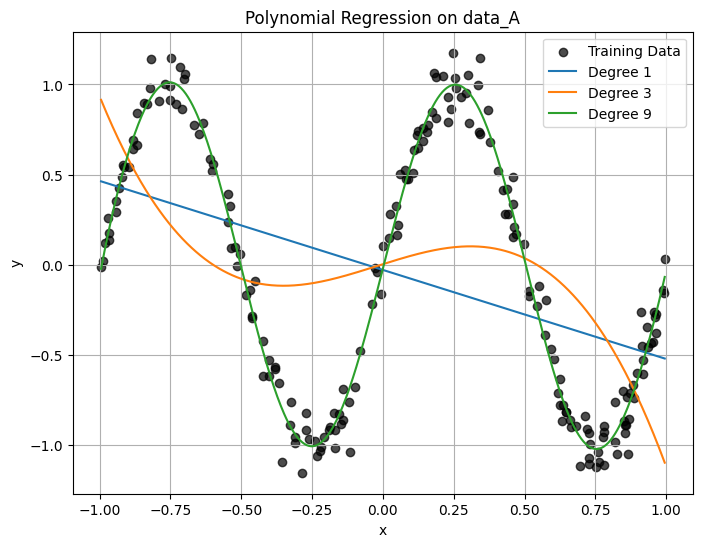

In [ ]:
plt.figure(figsize=(8, 6))

# plot training data
plt.scatter(x, y, color="black", label="Training Data", alpha=0.7)

# plot fitted curves
for d in degrees:
    X_grid = design_matrix(x_grid, d)
    y_pred = X_grid @ models[d]
    plt.plot(x_grid, y_pred, label=f"Degree {d}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression on data_A")
plt.legend()
plt.grid(True)
plt.show()


### ***Part B***

#### Load Training and Validation Sets

In Part B, we use the dataset `data_B`, which is already split into
training and validation sets. We will study the effect of polynomial
degree and ridge regularization on overfitting.

In [ ]:
train_path = "Q4_dataset/data_B_train.csv"
val_path = "Q4_dataset/data_B_val.csv"

train_data = pd.read_csv(train_path)
val_data = pd.read_csv(val_path)

x_train = train_data["x"].values
y_train = train_data["y"].values

x_val = val_data["x"].values
y_val = val_data["y"].values


#### Effect of Polynomial Degree

##### Mean Squared Error

We define the mean squared error (MSE) to evaluate model performance
on both training and validation sets.

In [ ]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

##### Degree Sweep Setup

We train polynomial regression models with degrees  
$d = 1, 2, \dots, 12$ using the normal equation and compute  
the training and validation MSE for each degree.


In [ ]:
degrees = range(1, 13)

train_mse = []
val_mse = []

for d in degrees:
    # training
    X_train = design_matrix(x_train, d)
    theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
    y_train_pred = X_train @ theta
    train_mse.append(mean_squared_error(y_train, y_train_pred))

    # validation
    X_val = design_matrix(x_val, d)
    y_val_pred = X_val @ theta
    val_mse.append(mean_squared_error(y_val, y_val_pred))


##### Plot MSE vs Degree

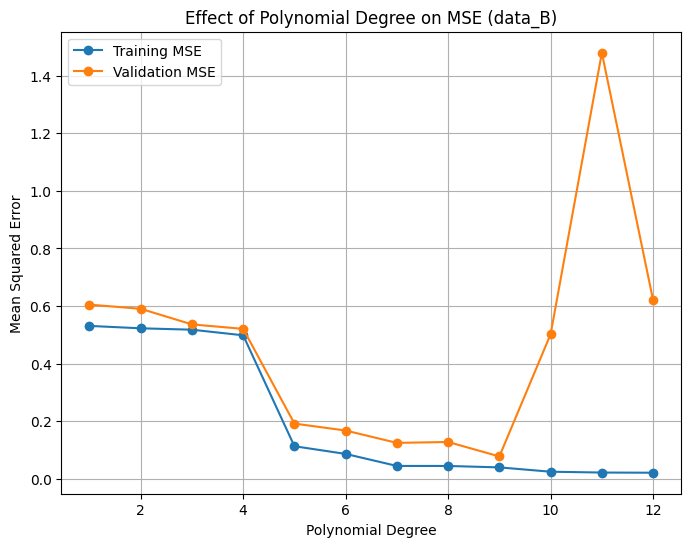

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(degrees, train_mse, marker="o", label="Training MSE")
plt.plot(degrees, val_mse, marker="o", label="Validation MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Polynomial Degree on MSE (data_B)")
plt.legend()
plt.grid(True)
plt.show()


#### Effect of Ridge Regularization

##### Ridge Regression Setup

We now fix the polynomial degree to $d = 12$ and study the effect  
of ridge regularization. The regularization parameter $\lambda$  
is varied on a logarithmic scale.


In [ ]:
lambdas = np.logspace(-6, 2, 50)

##### Ridge Regression Training

For each value of $\lambda$, we fit a ridge regression model using  
the closed-form solution and compute training and validation MSE.

In [ ]:
d = 12

X_train = design_matrix(x_train, d)
X_val = design_matrix(x_val, d)

train_mse_ridge = []
val_mse_ridge = []

I = np.eye(X_train.shape[1])

for lam in lambdas:
    theta = np.linalg.inv(X_train.T @ X_train + lam * I) @ X_train.T @ y_train

    y_train_pred = X_train @ theta
    y_val_pred = X_val @ theta

    train_mse_ridge.append(mean_squared_error(y_train, y_train_pred))
    val_mse_ridge.append(mean_squared_error(y_val, y_val_pred))


##### Plot MSE vs Lambda

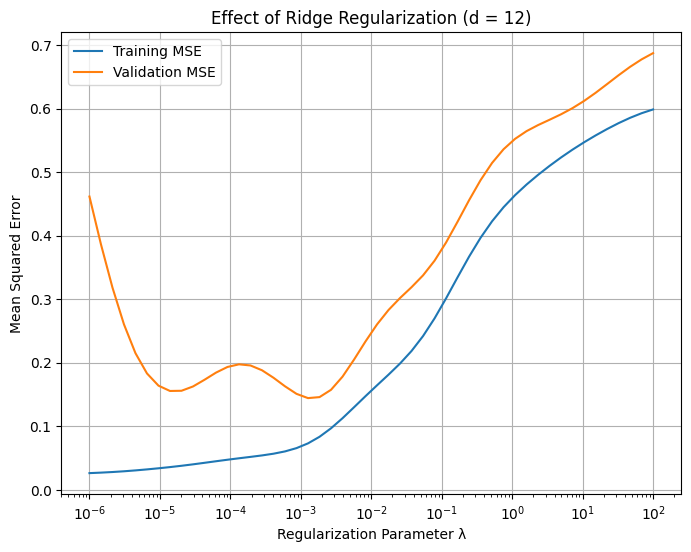

In [ ]:
plt.figure(figsize=(8, 6))
plt.semilogx(lambdas, train_mse_ridge, label="Training MSE")
plt.semilogx(lambdas, val_mse_ridge, label="Validation MSE")

plt.xlabel("Regularization Parameter λ")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Ridge Regularization (d = 12)")
plt.legend()
plt.grid(True)
plt.show()

## **Question 10 — Transfer Learning with Pre-trained Networks**

### **Overview**

In this experiment, we compare:

1. A shallow MLP trained from scratch
2. A frozen pre-trained VGG-11
3. A fine-tuned VGG-11

All experiments are conducted on the CIFAR-10 dataset.


### **Data Pre-processing**

#### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

#### Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#### Transforms

We normalize CIFAR-10 using dataset-specific statistics.


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])


#### Load Dataset

In [4]:
batch_size = 512

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 170M/170M [00:04<00:00, 34.9MB/s]


### **Model Architectures**

#### Model 1: MLP Baseline

Model 1: A simple Multi-Layer Perceptron operating on flattened CIFAR-10 images.
Input size: 32x32x3 = 3072.


In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)


#### Model 2: Frozen VGG-11

Model 2: Pre-trained VGG-11.  
All convolutional layers are frozen.  
Classifier is replaced for 10 classes.


In [6]:
def get_frozen_vgg():
    model = models.vgg11(pretrained=True)

    # Freeze feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    model.classifier[6] = nn.Linear(4096, 10)

    return model


#### Model 3: Fine-Tuned VGG-11

Model 3: Same as Model 2 but all layers are trainable.


In [7]:
def get_finetuned_vgg():
    model = models.vgg11(pretrained=True)
    model.classifier[6] = nn.Linear(4096, 10)
    return model


### **Training Procedure**

#### Training Utilities

We define helper functions for:
- Training one epoch
- Evaluating validation accuracy


In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # (a) Zero gradients
        optimizer.zero_grad()

        # (b) Forward pass
        outputs = model(images)

        # (c) Compute loss
        loss = criterion(outputs, labels)

        # (d) Backpropagation
        loss.backward()

        # (e) Update parameters
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


#### Training Configuration

Training setup:
- Optimizer: Adam
- Loss: CrossEntropyLoss
- Epochs: 10
- Batch size: 512


In [9]:
def train_model(model):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    train_losses = []
    val_accuracies = []

    for epoch in range(10):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc = evaluate(model, val_loader)

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/10 | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, val_accuracies


#### Train Model 1 (MLP)

In [10]:
mlp_model = MLP()
mlp_losses, mlp_acc = train_model(mlp_model)


Epoch 1/10 | Loss: 1.6679 | Val Acc: 0.4763
Epoch 2/10 | Loss: 1.4241 | Val Acc: 0.5043
Epoch 3/10 | Loss: 1.3048 | Val Acc: 0.5130
Epoch 4/10 | Loss: 1.2208 | Val Acc: 0.5177
Epoch 5/10 | Loss: 1.1314 | Val Acc: 0.5250
Epoch 6/10 | Loss: 1.0440 | Val Acc: 0.5282
Epoch 7/10 | Loss: 0.9658 | Val Acc: 0.5404
Epoch 8/10 | Loss: 0.8912 | Val Acc: 0.5364
Epoch 9/10 | Loss: 0.8237 | Val Acc: 0.5336
Epoch 10/10 | Loss: 0.7488 | Val Acc: 0.5400


#### Train Model 2 (Frozen VGG-11)

In [11]:
frozen_vgg = get_frozen_vgg()
frozen_losses, frozen_acc = train_model(frozen_vgg)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:08<00:00, 63.4MB/s]


Epoch 1/10 | Loss: 1.2201 | Val Acc: 0.6691
Epoch 2/10 | Loss: 1.0010 | Val Acc: 0.6948
Epoch 3/10 | Loss: 0.9481 | Val Acc: 0.6997
Epoch 4/10 | Loss: 0.9057 | Val Acc: 0.7045
Epoch 5/10 | Loss: 0.8805 | Val Acc: 0.7083
Epoch 6/10 | Loss: 0.8434 | Val Acc: 0.7124
Epoch 7/10 | Loss: 0.8241 | Val Acc: 0.7101
Epoch 8/10 | Loss: 0.7824 | Val Acc: 0.7130
Epoch 9/10 | Loss: 0.7634 | Val Acc: 0.7076
Epoch 10/10 | Loss: 0.7254 | Val Acc: 0.7137


#### Train Model 3 (Fine-Tuned VGG-11)

In [12]:
finetuned_vgg = get_finetuned_vgg()
finetuned_losses, finetuned_acc = train_model(finetuned_vgg)


Epoch 1/10 | Loss: 2.0649 | Val Acc: 0.2585
Epoch 2/10 | Loss: 1.5122 | Val Acc: 0.5316
Epoch 3/10 | Loss: 0.9418 | Val Acc: 0.7315
Epoch 4/10 | Loss: 0.6443 | Val Acc: 0.7970
Epoch 5/10 | Loss: 0.4636 | Val Acc: 0.8067
Epoch 6/10 | Loss: 0.3415 | Val Acc: 0.8061
Epoch 7/10 | Loss: 0.2514 | Val Acc: 0.8078
Epoch 8/10 | Loss: 0.1971 | Val Acc: 0.8201
Epoch 9/10 | Loss: 0.1409 | Val Acc: 0.8116
Epoch 10/10 | Loss: 0.1258 | Val Acc: 0.8236


### **Plot Results**

#### Plot Loss Curves

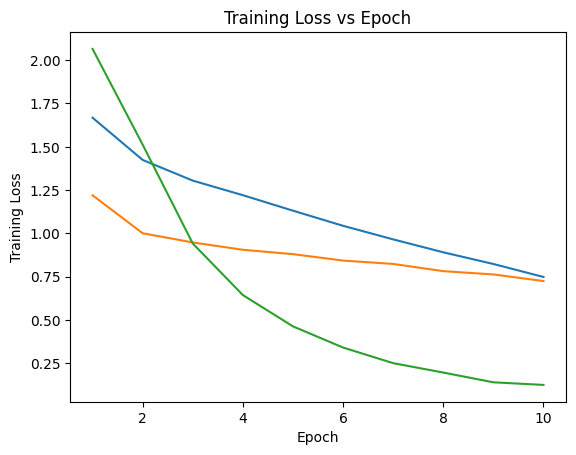

In [13]:
plt.figure()
plt.plot(range(1, 11), mlp_losses)
plt.plot(range(1, 11), frozen_losses)
plt.plot(range(1, 11), finetuned_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.show()


#### Plot Accuracy Curves

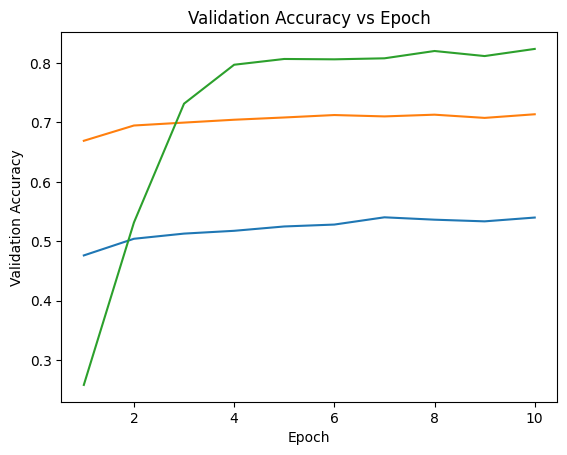

In [14]:
plt.figure()
plt.plot(range(1, 11), mlp_acc)
plt.plot(range(1, 11), frozen_acc)
plt.plot(range(1, 11), finetuned_acc)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.show()
